In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader

In [2]:
TRAIN_DIR = r"C:\Users\Abdullah\00 ML\projects\data\seg_train\seg_train"
VAL_DIR = r"C:\Users\Abdullah\00 ML\projects\data\seg_test\seg_test"

# Baseline Model

In [3]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [4]:
from PIL import Image
from torch.utils.data import Dataset

class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {}

        classes = sorted(os.listdir(root_dir))
        for idx, class_name in enumerate(classes):
            self.class_to_idx[class_name] = idx

        for class_name in classes:
            class_path = os.path.join(root_dir, class_name)
            
            if not os.path.isdir(class_path):
                continue

            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                
                self.image_paths.append(img_path)
                self.labels.append(self.class_to_idx[class_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [5]:
train_dataset = CustomImageDataset(TRAIN_DIR, transform=transform)
val_dataset   = CustomImageDataset(VAL_DIR, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.class_to_idx)
print(train_dataset.class_to_idx)

{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


### Baseline Model Code

In [6]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   
        )


        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)     # ensures fixed size regardless of input
        x = self.classifier(x)
        return x

In [7]:
device = torch.device('cuda')

model = BaselineCNN(6).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

model

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1):

In [10]:
epochs = 50
patience = 5         
best_val_loss = float('inf')
counter = 0
save_path = "best_model.pth"
best_model_state = None

In [11]:
for epoch in range(epochs):
    model.train()
    train_loss = 0
    train_correct = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()

    train_acc = train_correct / len(train_loader.dataset)

    model.eval()
    val_loss = 0
    val_correct = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()

    val_acc = val_correct / len(val_loader.dataset)

    print(f"Epoch {epoch+1} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        print("New Optimal Val Loss Found...")
        best_val_loss = val_loss
        counter = 0
        best_model_state = model.state_dict()  
        torch.save(model.state_dict(), save_path)
        
    else:
        counter += 1
        print(f"No improvement for {counter} epoch(s)")

        if counter >= patience:
            print("Early stopping triggered")
            break

Epoch 1 | Train Loss: 448.4041 | Train Acc: 0.5830 | Val Loss: 130.0304 | Val Acc: 0.4517
New Optimal Val Loss Found...
Epoch 2 | Train Loss: 336.3069 | Train Acc: 0.7082 | Val Loss: 63.8420 | Val Acc: 0.7227
New Optimal Val Loss Found...
Epoch 3 | Train Loss: 303.4398 | Train Acc: 0.7379 | Val Loss: 58.8224 | Val Acc: 0.7693
New Optimal Val Loss Found...
Epoch 4 | Train Loss: 284.3539 | Train Acc: 0.7639 | Val Loss: 66.9517 | Val Acc: 0.7287
No improvement for 1 epoch(s)
Epoch 5 | Train Loss: 266.4684 | Train Acc: 0.7773 | Val Loss: 54.6871 | Val Acc: 0.7947
New Optimal Val Loss Found...
Epoch 6 | Train Loss: 251.4970 | Train Acc: 0.7912 | Val Loss: 50.3025 | Val Acc: 0.8007
New Optimal Val Loss Found...
Epoch 7 | Train Loss: 242.8765 | Train Acc: 0.7980 | Val Loss: 44.8486 | Val Acc: 0.8337
New Optimal Val Loss Found...
Epoch 8 | Train Loss: 233.2539 | Train Acc: 0.8053 | Val Loss: 43.5725 | Val Acc: 0.8303
New Optimal Val Loss Found...
Epoch 9 | Train Loss: 226.3837 | Train Acc: 0.8

# Pretrained ResNet18 
### Partial Fine Tuning 
#### Only the FC Layer

In [80]:
from torchvision import models

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

In [81]:
num_classes = 6

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)

In [82]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [83]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [84]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

In [85]:
transform_res = transforms.Compose([
    transforms.Resize((224, 224)),          
    transforms.ToTensor(),                  
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],        
        std=[0.229, 0.224, 0.225]
    )
])

In [86]:
train_dataset = CustomImageDataset(TRAIN_DIR, transform=transform_res)
val_dataset = CustomImageDataset(VAL_DIR, transform=transform_res)

train_loader = DataLoader(train_dataset, batch_size= 32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [87]:
epochs = 50
best_val_loss = float('inf')
patience = 5
counter = 0

for epoch in range(epochs):
    model.train()
    train_loss, train_correct = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = outputs.argmax(1)
        train_correct += (preds == labels).sum().item()

    train_acc = train_correct / len(train_loader.dataset)

    model.eval()
    val_loss, val_correct = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = outputs.argmax(1)
            val_correct += (preds == labels).sum().sum().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / len(val_loader.dataset)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_resnet.pth")
        print("Saved best model")
    else:
        counter += 1
        if counter > patience:
            print("Early stopping")
            break

Epoch [1/50] | Train Acc: 0.8403 | Val Acc: 0.8843 | Val Loss: 0.3143
Saved best model
Epoch [2/50] | Train Acc: 0.8937 | Val Acc: 0.9033 | Val Loss: 0.2677
Saved best model
Epoch [3/50] | Train Acc: 0.8995 | Val Acc: 0.8963 | Val Loss: 0.2928
Epoch [4/50] | Train Acc: 0.8961 | Val Acc: 0.9090 | Val Loss: 0.2535
Saved best model
Epoch [5/50] | Train Acc: 0.9030 | Val Acc: 0.9023 | Val Loss: 0.2603
Epoch [6/50] | Train Acc: 0.9093 | Val Acc: 0.9107 | Val Loss: 0.2410
Saved best model
Epoch [7/50] | Train Acc: 0.9035 | Val Acc: 0.9113 | Val Loss: 0.2470
Epoch [8/50] | Train Acc: 0.9055 | Val Acc: 0.9097 | Val Loss: 0.2410
Epoch [9/50] | Train Acc: 0.9136 | Val Acc: 0.9043 | Val Loss: 0.2658
Epoch [10/50] | Train Acc: 0.9095 | Val Acc: 0.9130 | Val Loss: 0.2400
Saved best model
Epoch [11/50] | Train Acc: 0.9079 | Val Acc: 0.9120 | Val Loss: 0.2420
Epoch [12/50] | Train Acc: 0.9115 | Val Acc: 0.9050 | Val Loss: 0.2535
Epoch [13/50] | Train Acc: 0.9130 | Val Acc: 0.9117 | Val Loss: 0.2527
E

# Full Fine-tuning Using Discrimination Learner

In [88]:
model = models.resnet18(weights = models.ResNet18_Weights.DEFAULT)

num_classes = 6
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)

In [89]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [90]:
for param in model.parameters():
    param.requires_grad = True

### Discrimination Learning 
#### Different Learning Rate for different parameters

In [91]:
optimizer = torch.optim.Adam([
    {"params": model.fc.parameters(),     "lr": 1e-3},

    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.layer3.parameters(), "lr": 5e-5},
    {"params": model.layer2.parameters(), "lr": 2e-5},
    {"params": model.layer1.parameters(), "lr": 1e-5},

    {"params": model.conv1.parameters(),  "lr": 1e-6},
    {"params": model.bn1.parameters(),    "lr": 1e-6},
])

In [92]:
criterion = nn.CrossEntropyLoss()

### Training Loop

In [93]:
best_val_loss = float('inf')
patience = 5
epochs = 50
counter = 0

train_losses, val_losses = [] , []
train_accs, val_accs = [] , []

for epoch in range(epochs):
   
    model.train()
    train_correct = 0
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(1)
        train_correct += (preds == labels).sum().item()
        train_loss += loss.item()

    train_acc = train_correct / len(train_loader.dataset)
    train_accs.append(train_acc)
    train_losses.append(train_loss / len(train_loader))

    model.eval()
    val_loss = 0
    val_correct = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = outputs.argmax(1)
            val_correct += (preds == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / len(val_loader.dataset)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {train_acc:.4f} | "
          f"Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_resnet_ft.pth")
    else:
        counter += 1
        print(f"Validation Metrics not improved for {counter} times")
        if counter > patience:
            print("Early stopping executed")
            break

Epoch [1/50] | Train Acc: 0.9032 | Val Acc: 0.9313 | Val Loss: 0.2006
Epoch [2/50] | Train Acc: 0.9596 | Val Acc: 0.9277 | Val Loss: 0.2195
Validation Metrics not improved for 1 times
Epoch [3/50] | Train Acc: 0.9828 | Val Acc: 0.9220 | Val Loss: 0.3003
Validation Metrics not improved for 2 times
Epoch [4/50] | Train Acc: 0.9890 | Val Acc: 0.9297 | Val Loss: 0.2766
Validation Metrics not improved for 3 times
Epoch [5/50] | Train Acc: 0.9875 | Val Acc: 0.9303 | Val Loss: 0.2862
Validation Metrics not improved for 4 times
Epoch [6/50] | Train Acc: 0.9896 | Val Acc: 0.9177 | Val Loss: 0.3158
Validation Metrics not improved for 5 times
Epoch [7/50] | Train Acc: 0.9903 | Val Acc: 0.9377 | Val Loss: 0.2915
Validation Metrics not improved for 6 times
Early stopping executed


### Plotting Accuracy and Loss 

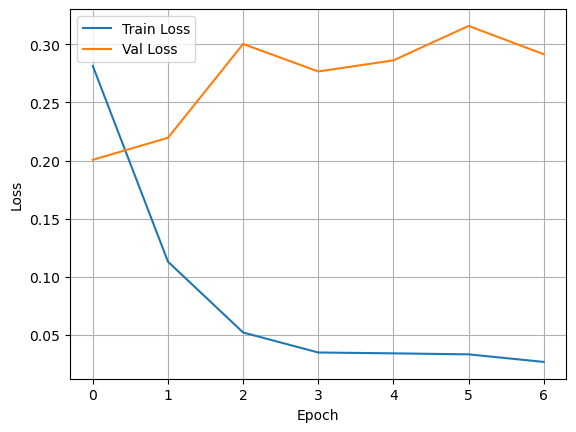

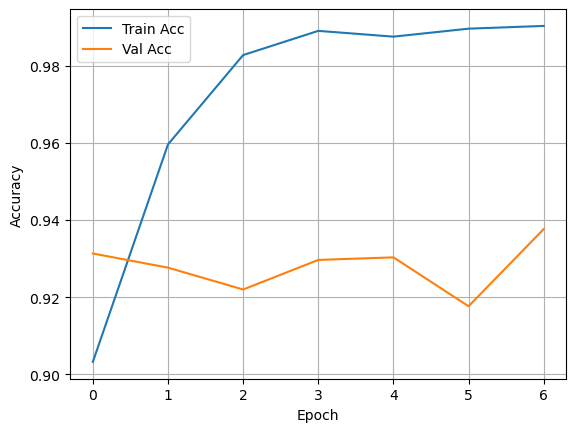

In [94]:
epoch_arr = list(range(len(val_losses)))

plt.figure()
plt.plot(epoch_arr, train_losses, label='Train Loss')
plt.plot(epoch_arr, val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epoch_arr, train_accs, label='Train Acc')
plt.plot(epoch_arr, val_accs, label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ConvNeXt Tiny Model Fine-tuning
### Custom Fully Connected Laye

In [ ]:
import timm

NUM_CLASSES = 6

model = timm.create_model(
    "convnext_tiny",
    pretrained=True,
    num_classes=0 
)

model.head.fc = nn.Sequential(
    nn.Linear(768, 512),
    nn.GELU(),
    nn.Dropout(0.2),

    nn.Linear(512, 256),
    nn.GELU(),
    nn.Dropout(0.3),

    nn.Linear(256, 128),
    nn.GELU(),
    nn.Dropout(0.2),

    nn.Linear(128, 64),
    nn.GELU(),
    nn.Dropout(0.2),

    nn.Linear(64, NUM_CLASSES)
)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(model)

ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (fc2): Linear(in_features=384, out_features=96, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)


In [9]:
for param in model.parameters():
    param.requires_grad = False

# unfreeze only head
for param in model.head.parameters():
    param.requires_grad = True

### Unfreeze Last Blocks of ConvNeXt

In [15]:
for name, param in model.named_parameters():
    if "stages.3" in name or "head" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

In [16]:
backbone_params = []
head_params = []

for name, param in model.named_parameters():
    if "head" in name:
        head_params.append(param)
    else:
        backbone_params.append(param)
        
optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": 1e-4},
    {"params": head_params, "lr": 1e-3}
], weight_decay=0.05)

In [17]:
print(model.head)

NormMlpClassifierHead(
  (global_pool): SelectAdaptivePool2d(pool_type=avg, flatten=Identity())
  (norm): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (pre_logits): Identity()
  (drop): Dropout(p=0.0, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=64, bias=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=6, bias=True)
  )
)


In [18]:
criterion = nn.CrossEntropyLoss(reduction="mean")

#### Transform for ConvNeXt Compabitibility

In [19]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.RandomGrayscale(p=0.05),

    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),

    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [23]:
train_dataset = CustomImageDataset(TRAIN_DIR, transform = train_transform)
val_dataset = CustomImageDataset(VAL_DIR, transform = val_transform)

train_loader = DataLoader(train_dataset, batch_size = 256, shuffle = True)
val_loader   = DataLoader(val_dataset, batch_size = 16, shuffle = False)

### Training Loop

In [26]:
epochs = 20
best_acc = 0.0

patience = 5
min_delta = 1e-4
patience_counter = 0

train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total


    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

   
    if val_acc > best_acc + min_delta:
        best_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_convnext_model.pth")
        print("Best model saved!")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("Early stopping triggered!")
        break

Epoch [1/20]
Train Loss: 0.1454 | Train Acc: 0.9525
Val   Loss: 0.1536 | Val   Acc: 0.9480
Best model saved!
Epoch [2/20]
Train Loss: 0.1263 | Train Acc: 0.9586
Val   Loss: 0.1505 | Val   Acc: 0.9523
Best model saved!
Epoch [3/20]
Train Loss: 0.1135 | Train Acc: 0.9616
Val   Loss: 0.1502 | Val   Acc: 0.9547
Best model saved!
Epoch [4/20]
Train Loss: 0.0953 | Train Acc: 0.9676
Val   Loss: 0.1494 | Val   Acc: 0.9537
No improvement. Patience: 1/5
Epoch [5/20]
Train Loss: 0.0829 | Train Acc: 0.9708
Val   Loss: 0.1627 | Val   Acc: 0.9513
No improvement. Patience: 2/5
Epoch [6/20]
Train Loss: 0.0838 | Train Acc: 0.9711
Val   Loss: 0.1530 | Val   Acc: 0.9533
No improvement. Patience: 3/5
Epoch [7/20]
Train Loss: 0.0645 | Train Acc: 0.9791
Val   Loss: 0.1752 | Val   Acc: 0.9493
No improvement. Patience: 4/5
Epoch [8/20]
Train Loss: 0.0642 | Train Acc: 0.9793
Val   Loss: 0.1700 | Val   Acc: 0.9503
No improvement. Patience: 5/5
Early stopping triggered!


### Accuracy and Loss Graph

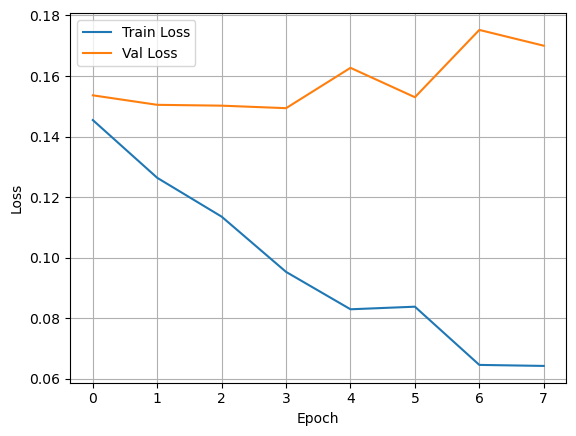

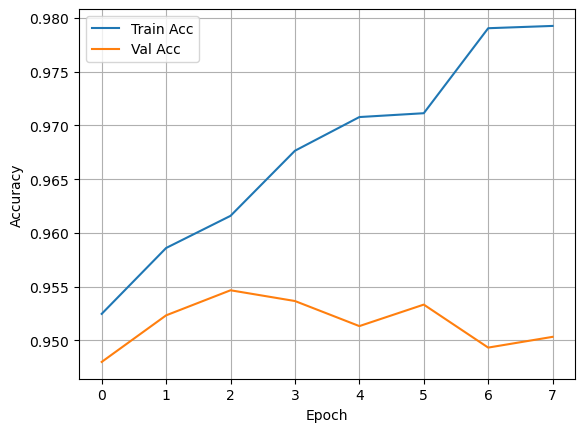

In [27]:
epoch_arr = list(range(len(val_losses)))

plt.figure()
plt.plot(epoch_arr, train_losses, label='Train Loss')
plt.plot(epoch_arr, val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epoch_arr, train_accs, label='Train Acc')
plt.plot(epoch_arr, val_accs, label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()